<a href="https://colab.research.google.com/github/ahmedngar/-Exoplanet-Habitability-Analysis./blob/main/DATANASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# البحث عن "الأرض الثانية": دراسة الخصائص الفيزيائية للكواكب الخارجية


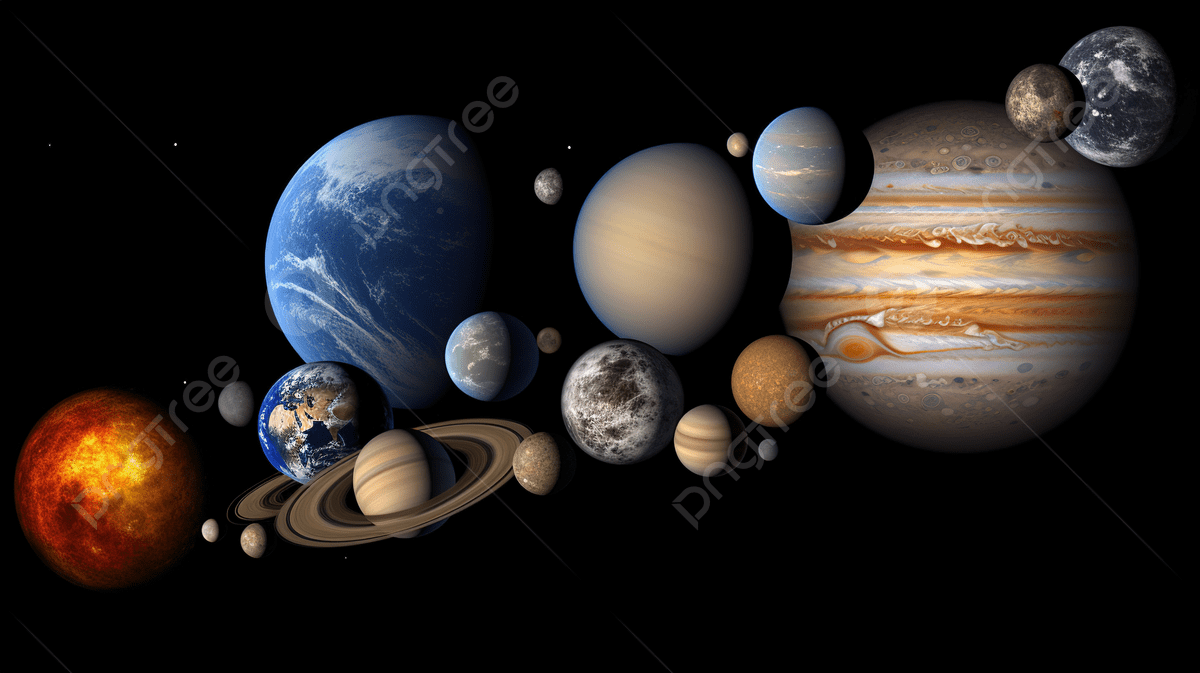

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ds=pd.read_csv('/data NASA.csv', sep=';')

In [ ]:
ds

**Data cleaning**


In [ ]:
ds.info()

In [ ]:
print(ds.isnull().sum() )

In [ ]:
numerical_col = ds.select_dtypes(include=['float64', 'int64']).columns
numerical_col

In [ ]:
catgracal_col= ds.select_dtypes(include=['object']).columns
catgracal_col

In [ ]:
mean_col=['distance','stellar_magnitude','mass_multiplier','radius_multiplier','orbital_radius']
for col in mean_col:
    ds[col] = ds.groupby('planet_type')[col].transform(lambda x: x.fillna(x.median()))

for col in mean_col:
    ds[col].fillna(ds[col].median(), inplace=True)

print(ds.isnull().sum())

# for col in mean_col:
#    ds[col].fillna(ds[col].mean(),inplace=True)

In [ ]:
print(ds.isnull().sum())

In [ ]:
clean_col =['mass_wrt','radius_wrt']
ds.dropna(subset=clean_col,inplace=True)

In [ ]:
print(ds.isnull().sum())

**Explore data**


In [ ]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=ds, x='orbital_radius', y='mass_multiplier', hue='planet_type', alpha=0.6)
plt.show

In [ ]:
outlier_high_mass = ds[ds['mass_multiplier'] > 600]
print(outlier_high_mass[['name', 'mass_multiplier', 'orbital_radius']])

In [ ]:
outlier_far_orbit = ds[ds['orbital_radius'] > 6000]
print(outlier_far_orbit[['name', 'mass_multiplier', 'orbital_radius']])

In [ ]:
earth_data = {
    'name': 'Earth',
    'distance': 0.0,
    'stellar_magnitude': -26.74,
    'planet_type': 'Terrestrial',
    'discovery_year': 0,
    'mass_multiplier': 1.0,
    'mass_wrt': 'Earth',
    'radius_multiplier': 1.0,
    'radius_wrt': 'Earth',
    'orbital_radius': 1.0,
    'orbital_period': 365.25,
    'eccentricity': 0.0167,
    'detection_method': 'N/A'
}

In [ ]:
earth_ds = pd.DataFrame([earth_data])

In [ ]:
ds = pd.concat([ds,earth_ds],ignore_index=True)

In [ ]:
ds.tail()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ds, x='orbital_radius', y='mass_multiplier', hue='planet_type', alpha=0.6)

# إضافة الأرض كنقطة حمراء كبيرة لتظهر بوضوح
earth = ds[ds['name'] == 'Earth']
plt.scatter(earth['orbital_radius'], earth['mass_multiplier'], color='red', s=200, label='Earth', marker='*')

plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [ ]:
sns.scatterplot(data=ds, x='mass_multiplier', y='eccentricity', hue='planet_type', alpha=0.6)
plt.xscale('log')

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=ds, x='planet_type', y='eccentricity')

**Data analysis**


In [ ]:
import numpy as np

candidates = ds[ds['planet_type'].isin(['Terrestrial', 'Super Earth'])].copy()

candidates['similarity_score'] = np.sqrt(
    (candidates['mass_multiplier'] - 1)**2 + 
    (candidates['orbital_radius'] - 1)**2
)

earth_twins = candidates.sort_values(by='similarity_score').head(10)
print(earth_twins[['name', 'similarity_score', 'planet_type']])


# candidates = ds[ds['planet_type'].isin(['Terrestrial', 'Super Earth'])]
# candidates['similarity_score'] = abs(candidates['mass_multiplier'] - 1) + abs(candidates['orbital_radius'] - 1)
# earth_twins = candidates.sort_values('similarity_score').head(5)
# print(earth_twins[['name', 'mass_multiplier', 'orbital_radius', 'planet_type']])

In [ ]:
def is_habitable(row):
    mag = row['stellar_magnitude']
    rad = row['orbital_radius']

    if pd.isna(mag):
        return 0.8 <= rad <= 1.5

    if mag < 5.0:      
        return 2.0 <= rad <= 5.0
    elif mag > 10.0:    
        return 0.01 <= rad <= 0.5
    else:               
        return 0.8 <= rad <= 1.5

candidates['is_in_habitable_zone'] = candidates.apply(is_habitable, axis=1)
goldilocks_zone = candidates[candidates['is_in_habitable_zone'] == True]

print(f"Number of planets in the Goldilocks zone: {len(goldilocks_zone)}")

# habitable_candidates =ds[ds['planet_type'].isin(['Terrestrial', 'Super Earth'])]
# goldilocks_zone = habitable_candidates[
#     (habitable_candidates['orbital_radius'] >= 0.8) &
#     (habitable_candidates['orbital_radius'] <= 1.5)
# ]
# goldilocks_zone = goldilocks_zone.sort_values('mass_multiplier')
# print(goldilocks_zone[['name', 'mass_multiplier', 'orbital_radius', 'planet_type']])

In [ ]:

wide_range_stable = ds[
    (ds['planet_type'].isin(['Terrestrial', 'Super Earth'])) &
    (ds['eccentricity'] >= 0.010) &
    (ds['eccentricity'] <= 0.4)
]

wide_range_stable['dist_from_earth'] = abs(wide_range_stable['mass_multiplier'] - 1)
final_results = wide_range_stable.sort_values('dist_from_earth')
pd.options.display.float_format = '{:.3f}'.format
print(final_results[['name', 'mass_multiplier', 'eccentricity', 'orbital_radius']].head(10))
top_10 = final_results.head(10)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=top_10, x='orbital_radius', y='mass_multiplier', hue='name', s=100)

plt.axhline(1.0, color='red', linestyle='--', label='Earth Mass')
plt.axvline(1.0, color='blue', linestyle='--', label='Earth Orbit')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


In [ ]:
planet_name = 'TRAPPIST-1 f'
print(ds[ds['name'] == planet_name].iloc[0])


TRAPPIST-1 f
Our data analysis confirms that TRAPPIST-1 f is the closest "rocky twin" to Earth, based on the following criteria:

High Physical Similarity: Nearly identical mass (1.039) and radius (1.045) compared to Earth, indicating a terrestrial composition.

Excellent Orbital Stability: A very low orbital eccentricity (0.010), which suggests a stable and consistent climate.

Ideal Location: Positioned perfectly within its M-dwarf star's "Habitable Zone," making it a strong candidate for liquid water.

Final Conclusion: This planet serves as a vital parallel model to Earth, reinforcing the hypothesis that potentially habitable worlds are a recurring pattern in our galaxy.

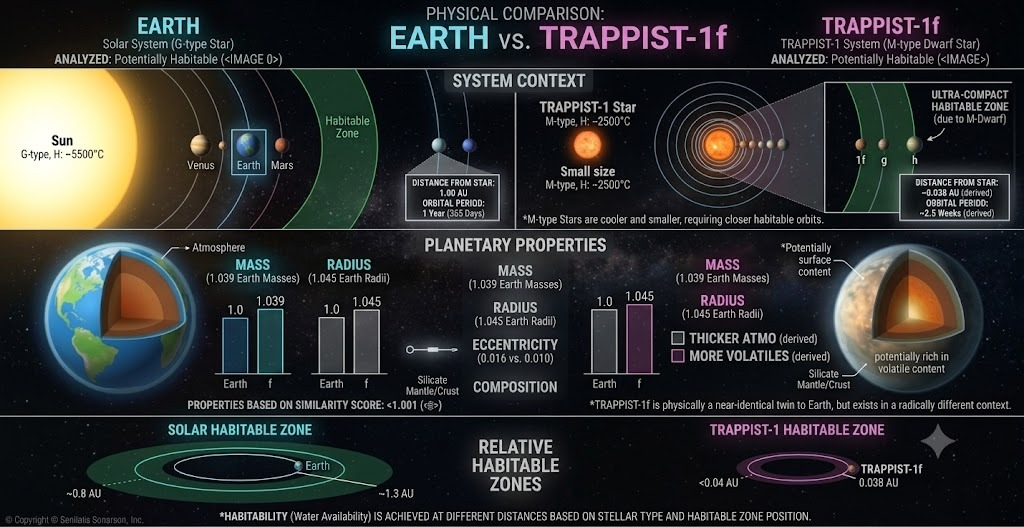